In [21]:
# Data Manipulation
import numpy as np
import pandas as pd
import yfinance as yf

# Technical Indicators
import talib as ta

# Plotting graphs
import matplotlib.pyplot as plt

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [22]:
# Pull NIFTY data from Yahoo finance
df = yf.download('AAPL','2005-01-01', '2023-12-30', group_by='ticker')['AAPL']

df['S_10'] = df['Close'].rolling(window=10).mean()
df['Corr'] = df['Close'].rolling(window=10).corr(df['S_10'])
df['RSI'] = ta.RSI(np.array(df['Close']), timeperiod =10)
df['Open-Close'] = df['Open'] - df['Close'].shift(1)
df['Open-Open'] = df['Open'] - df['Open'].shift(1)
df = df.dropna()
X = df.iloc[:,:9]
y = np.where(df['Close'].shift(-1) > df['Close'],1,-1)

split = int(0.7*len(df))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

model = LogisticRegression()
model = model.fit (X_train,y_train)

[*********************100%***********************]  1 of 1 completed


In [23]:
pd.DataFrame(zip(X.columns, np.transpose(model.coef_)))

,0,1
0,Open,[0.000240022306760659]
1,High,[0.0002404189751385917]
2,Low,[0.0002377727668835935]
3,Close,[0.00023611010602565152]
4,Volume,[-1.5637216732176563e-11]
5,S_10,[0.0002313716367230133]
6,Corr,[1.512463609540391e-05]
7,RSI,[0.0016066713910390543]
8,Open-Close,[1.1348544289412537e-06]


In [24]:
# Specify the start and end dates for prediction
start_date = '2019-12-22'
end_date = '2024-01-01'

# Create a list containing the start and end dates
prediction_date = [start_date, end_date]

# Use the list of dates for prediction
probability = model.predict_proba(X_test)
print(probability)

predicted = model.predict(X_test)

print (predicted)

# Define predicted_labels as buy signal (1)
predicted_labels = 1

# Find the dates with predicted buy signals (Signal = 1)
buy_signal_dates = prediction_date[predicted_labels == 1]

# Print the date(s) with buy signal(s)
print("\nDate(s) with Buy Signal(s):")
print(buy_signal_dates)
print(predicted)

print(metrics.confusion_matrix(y_test, predicted))

df['Predicted_Signal'] = model.predict(X)
df['AAPL_returns'] = np.log(df['Close']/df['Close'].shift(1))
Cumulative_AAPL_returns = np.cumsum(df[split:]['AAPL_returns'])


df['Strategy_returns'] = df['AAPL_returns']* df['Predicted_Signal'].shift(1)
Cumulative_Strategy_returns = np.cumsum(df[split:]['Strategy_returns'])

[[0.47610449 0.52389551]
 [0.4724886  0.5275114 ]
 [0.46864874 0.53135126]
 ...
 [0.42457427 0.57542573]
 [0.42344524 0.57655476]
 [0.42559295 0.57440705]]
[1 1 1 ... 1 1 1]

Date(s) with Buy Signal(s):
2024-01-01
[1 1 1 ... 1 1 1]
[[  0 663]
 [  0 766]]


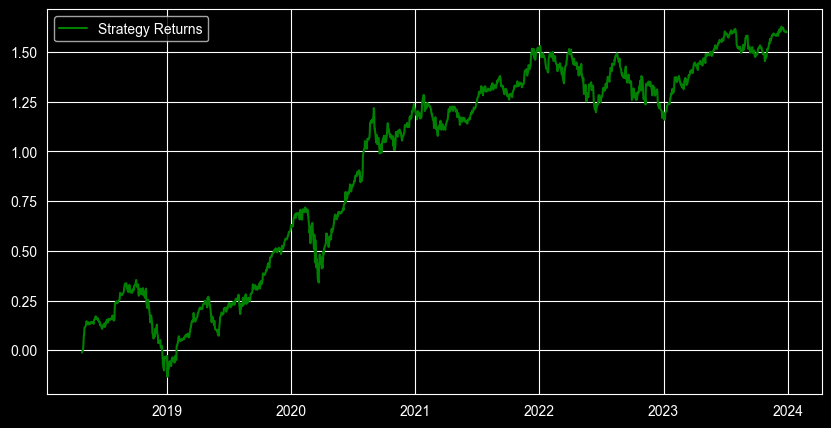

In [25]:
plt.figure(figsize=(10,5))
plt.plot(Cumulative_Strategy_returns, color='g', label = 'Strategy Returns')
plt.legend()
plt.show()